In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
# TV Reklam Bütçesi (Bin TL) ve Karşılığındaki Satışlar (Bin Adet)
veri = {
    'TV_Butcesi': [230, 44, 17, 151, 280, 8, 57, 120, 214, 23, 290, 100, 160, 200, 50],
    'Satislar': [22, 10, 9, 18, 26, 4, 11, 15, 19, 7, 28, 14, 17, 21, 12]
}

df = pd.DataFrame(veri)
df.head()

,TV_Butcesi,Satislar
0,230,22
1,44,10
2,17,9
3,151,18
4,280,26


In [3]:
# 1. Özellik (X) ve Hedef (y) ayrımı
X = df[['TV_Butcesi']]
y = df['Satislar']

# 2. Veriyi %80 Eğitim ve %20 Test olacak şekilde rastgele ikiye bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim (Train) seti satır sayısı: {len(X_train)}")
print(f"Test seti satır sayısı: {len(X_test)}")

Eğitim (Train) seti satır sayısı: 12
Test seti satır sayısı: 3


In [4]:
# 1. Doğrusal Regresyon modelini çağırıyoruz
model = LinearRegression()

# 2. Modeli eğitiyoruz
model.fit(X_train, y_train)

# 3. Modelin bulduğu matematiksel formülün parçalarını görelim (y = ax + b)
print(f"Eğim (a - Katsayı): {model.coef_[0]}")
print(f"Sabit (b - Başlangıç): {model.intercept_}")

Eğim (a - Katsayı): 0.06992164604159623
Sabit (b - Başlangıç): 6.562888428985033


Satış = 0.069 * Bütçe + 6.56

In [5]:
tahminler = model.predict(X_test)

kiyas_tablosu = pd.DataFrame({
    'Gerçek Satışlar': y_test, 
    'Modelin Tahmini': tahminler
})
print(kiyas_tablosu)

    Gerçek Satışlar  Modelin Tahmini
9                 7         8.171086
11               14        13.555053
0                22        22.644867


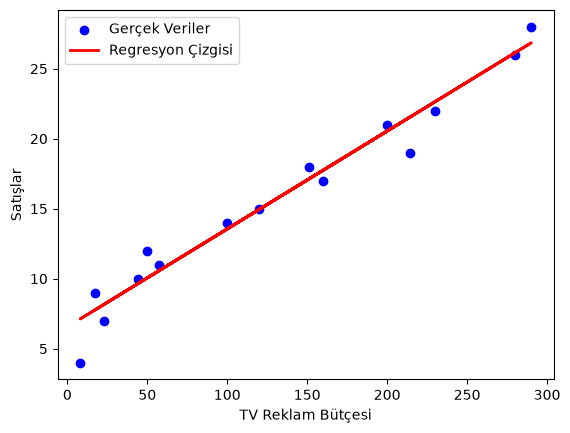

In [6]:
plt.scatter(X, y, color='blue', label='Gerçek Veriler')

plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regresyon Çizgisi')

plt.xlabel('TV Reklam Bütçesi')
plt.ylabel('Satışlar')
plt.legend()
plt.show()

In [7]:
yeni_butce = [[350]]
beklenen_satis = model.predict(yeni_butce)

print(f"350 bin TL bütçe ile beklenen satış: {beklenen_satis[0]:.2f} bin adet")

350 bin TL bütçe ile beklenen satış: 31.04 bin adet


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [8]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print(f"MSE (Hata Kareler Ortalaması): {mse:.2f}")
print(f"R-Kare (Başarı Notu): {r2:.2f}")

MSE (Hata Kareler Ortalaması): 0.66
R-Kare (Başarı Notu): 0.98
